# Random Forest Regression
- Random Forest Regression is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It uses the principle of bagging (bootstrap aggregating), where:

1. Multiple Decision Trees: The algorithm builds several decision trees independently, each trained on a different random subset of the data (with replacement).
2. Random Subset of Features: At each split in the tree, only a random subset of features is considered, ensuring diversity among trees.
3. Aggregation of Predictions: For regression tasks, the final prediction is the average of predictions from all the individual trees.

#### Key Intuitions
Diversity through Randomization: By training trees on different subsets of data and features, the model reduces the likelihood of overfitting.
Strength in Numbers: Combining multiple weak learners (trees) creates a robust and accurate model.
Reduced Variance: Aggregating predictions stabilizes the model and makes it less sensitive to noise in the data.

#### Steps in Random Forest Regression:
1. Splitting the Data: Randomly select a subset of the features and split the data into training and testing sets.
2. Building Multiple Decision Trees: Train individual decision trees on different subsets of the data.
3. Random Feature Selection: For each split, randomly select a subset of features.
4. Aggregating Predictions: Combine the predictions from all the trees to create a final prediction.
5. Hyperparameter Tuning: Tune the number of trees, maximum depth, and other parameters to improve model performance.

#### Use Cases
- Predicting Continuous Values:
House prices, sales forecasting, stock prices.
- Handling Non-Linear Relationships:
Complex relationships between features and target variables.
- Feature Importance Analysis:
Understanding which features significantly impact the predictions.
- Imbalanced or Noisy Data:
Handles missing values and noisy data better than individual decision trees.

#### Advantages
- High Accuracy: Outperforms individual decision trees by reducing variance.
- Robustness: Less prone to overfitting due to averaging.
- Handles Non-Linearity: Can model complex, non-linear relationships.
- Feature Importance: Provides insights into feature contributions.

#### Limitations
- Computationally Intensive: Training multiple trees can be resource-heavy.
- Less Interpretability: Harder to explain than a single decision tree.
- Bias in Regression: May not capture extreme values effectively due to averaging.
* In summary, Random Forest Regression is a powerful, versatile method suitable for tasks where accuracy and robustness are priorities, especially with complex or noisy datasets.

## Importing the Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

## Loading the Dataset

In [2]:
dataset = pd.read_csv('Position_Salaries.csv')
dataset

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000
5,Region Manager,6,150000
6,Partner,7,200000
7,Senior Partner,8,300000
8,C-level,9,500000
9,CEO,10,1000000


In [3]:
X = dataset.iloc[:, 1:-1].values
y = dataset.iloc[:, -1].values

## Training the Random Forest Regression model

In [4]:
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X, y)

RandomForestRegressor(n_estimators=10, random_state=0)

## Predicting a new result

In [5]:
regressor.predict([[6.5]])

array([167000.])

## Visualizing the Random Forest Regression results (salary) - higher resolution

/var/folders/x4/dd2xz8_d4fjbb7kzdq5sp8_40000gn/T/ipykernel_20474/3385567373.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


Text(0.5, 0, 'Position level')

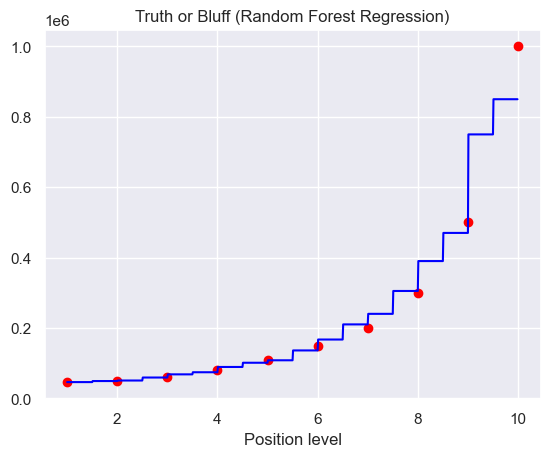

In [7]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color ='red')
plt.plot(X_grid, regressor.predict(X_grid), color = 'blue')
plt.title('Truth or Bluff (Random Forest Regression)')
plt.xlabel('Position level')

## Evaluating the model - Calculating the R-squared and Adjusted R-squared

In [9]:
# Calculating the R-squared
r2 = regressor.score(X, y)
# Calculating the Adjusted R-squared
n = X.shape[0]
k = X.shape[1]
adjusted_r2 = 1-(1-r2)*(n-1)/(n-k-1)
# np.set_printoptions(precision=2)
print(f'R-squared: {r2:.3f}, Adjusted R-squared: {adjusted_r2:.3f}')

R-squared: 0.970, Adjusted R-squared: 0.967
